# Predictive microbial ecology

In this notebook, we will predict disbiosis according based on sample metadata and micribial features. We will use the data preprocessed in notebook "10_descriptive_statistics.ipynb". We will assess the contribution of these features to the prediction of health and disease (Chron's Disease, or Ulcerative colitis). 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import shap

sns.set(style="whitegrid")
%matplotlib inline

# Define Paths

In [ ]:
# Paths

BASE_PATH= Path.cwd().resolve().parent
DATA_PATH = BASE_PATH / "dataset"
RESULTS_PATH = BASE_PATH / "raw_results"

# Figures directory
FIG_PATH = BASE_PATH / "figures"

# Tables directory
TABLE_PATH = BASE_PATH / "results_tables"


# Load data

We load three files: 
1) biology data, merging taxa from qiime2 + functions from picrust2.
2) metadata preprocesed (only keeping features fully reported and non-constant)
3) biology + metadata

We will build a random forest model for each dataset

In [96]:
df_micro = pd.read_csv(TABLE_PATH / "df_micro_for_ml.csv", sep=",", index_col=0)
print(df_micro.shape)
df_meta = pd.read_csv(TABLE_PATH / "df_meta_for_ml.csv", sep=",", index_col=0)
print(df_meta.shape)
df_combined = pd.read_csv(TABLE_PATH / "df_micro_meta_for_ml.csv", sep=",", index_col=0)
print(df_combined.shape)    


(165, 913)
(178, 23)
(165, 936)


In [100]:
df_meta.head()


,Project,sample-id,site_sub_coll,visit_num,IntervalName,IntervalSequence,ProjectSpecificID,site_name,Occupation,Number of flora tubes collected:,...,diagnosis,Aphthous ulcers,Abscess,Hispanic or Latino Origin,Was subject terminated by investigator?,is_inflamed,Partial Endoscopy,race,Partial Endoscopy.1,sex
External ID,,,,,,,,,,,,,,,,,,,,,
206615,C3001CSC1_BP,C3001,C3001CSC1,1,Screening Colonoscopy,1,3001,Cedars-Sinai,Paid,2.0,...,CD,No,No,Not Hispanic or Latino,No,Yes,No,White,No,Female
206614,C3001CSC2_BP,C3001,C3001CSC2,1,Screening Colonoscopy,1,3001,Cedars-Sinai,Paid,2.0,...,CD,No,No,Not Hispanic or Latino,No,Yes,No,White,No,Female
206617,C3002CSC1_BP,C3002,C3002CSC1,1,Screening Colonoscopy,1,3002,Cedars-Sinai,Retired,4.0,...,CD,No,No,Not Hispanic or Latino,No,Yes,No,White,No,Female
206619,C3002CSC2_BP,C3002,C3002CSC2,1,Screening Colonoscopy,1,3002,Cedars-Sinai,Retired,4.0,...,CD,No,No,Not Hispanic or Latino,No,Yes,No,White,No,Female
206616,C3002CSC3_BP,C3002,C3002CSC3,1,Screening Colonoscopy,1,3002,Cedars-Sinai,Retired,4.0,...,CD,No,No,Not Hispanic or Latino,No,Yes,No,White,No,Female


# Random forest classifier

Shapes:
Micro: (165, 913)
Meta: (165, 11)
Combined: (165, 924)
Target: (165,)

=== Microbiome Only ===
CV Accuracy: 0.685 ± 0.056

Classification report:
              precision    recall  f1-score   support

          CD       0.65      0.95      0.77        81
          UC       0.85      0.28      0.42        39
      nonIBD       0.74      0.56      0.63        45

    accuracy                           0.68       165
   macro avg       0.74      0.60      0.61       165
weighted avg       0.72      0.68      0.65       165



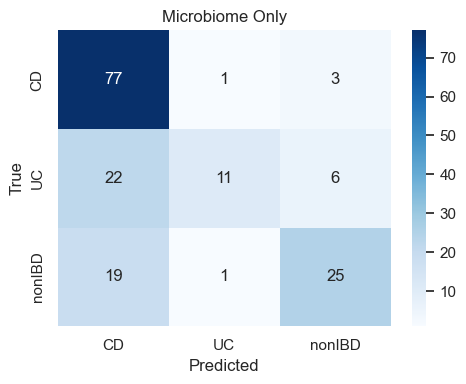


=== Metadata Only ===
CV Accuracy: 0.588 ± 0.031

Classification report:
              precision    recall  f1-score   support

          CD       0.57      0.69      0.62        81
          UC       0.69      0.46      0.55        39
      nonIBD       0.57      0.51      0.54        45

    accuracy                           0.59       165
   macro avg       0.61      0.55      0.57       165
weighted avg       0.60      0.59      0.58       165



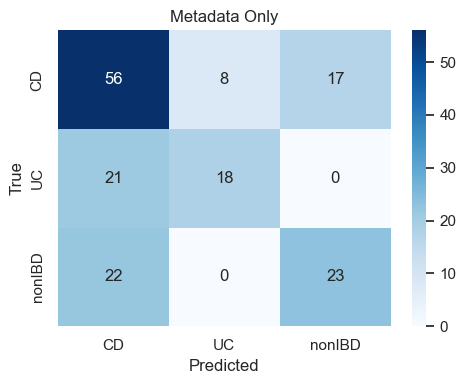


=== Combined Model ===
CV Accuracy: 0.703 ± 0.067

Classification report:
              precision    recall  f1-score   support

          CD       0.68      0.95      0.79        81
          UC       0.86      0.31      0.45        39
      nonIBD       0.71      0.60      0.65        45

    accuracy                           0.70       165
   macro avg       0.75      0.62      0.63       165
weighted avg       0.73      0.70      0.67       165



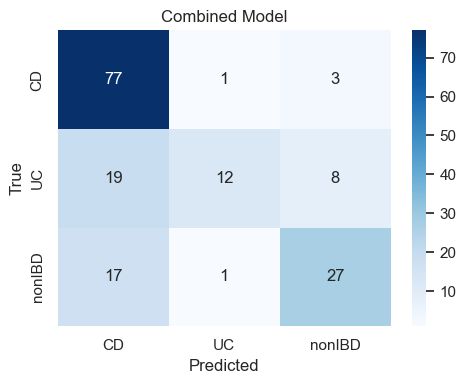

In [128]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. ALIGN DATASETS
# -----------------------
common_idx = df_micro.index.intersection(df_meta.index)

df_micro = df_micro.loc[common_idx]
df_meta = df_meta.loc[common_idx]
df_combined = df_combined.loc[common_idx]

# -----------------------
# 2. DEFINE TARGET
# -----------------------
y = df_meta['diagnosis'].astype('category')
class_names = y.cat.categories.tolist()

# -----------------------
# 3. DEFINE ID COLUMNS (DROP THESE ONLY)
# -----------------------
id_like = [
    'Project', 'sample-id', 'ProjectSpecificID', 'site_sub_coll'
]

clinical_leakage = [
    'Have samples been sent for histopathology?',
    'Abscess',
    'Aphthous ulcers',
    'is_inflamed',
    'Partial Endoscopy',
    'Partial Endoscopy.1'
]

batch_like = [
    'site_name',
    'ECP received at Washington U'
]

cols_to_drop = id_like + clinical_leakage + batch_like

#X_meta_clean = X_meta.drop(columns=[c for c in cols_to_drop if c in X_meta.columns])

# -----------------------
# 4. PREPROCESS FUNCTION
# -----------------------
def preprocess_df(X, drop_cols=None):
    X = X.copy()
    
    # Drop ID columns only
    if drop_cols is not None:
        X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors='ignore')
    
    # Encode categorical variables
    for col in X.select_dtypes(include=['object', 'category']).columns:
        X[col] = X[col].astype('category').cat.codes
    
    # Replace inf / nan
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    
    return X

# -----------------------
# 5. BUILD FEATURE MATRICES
# -----------------------
X_micro = preprocess_df(df_micro, drop_cols=cols_to_drop)

X_meta = preprocess_df(
    df_meta.drop(columns=['diagnosis']),
    drop_cols=cols_to_drop
)

X_combined = preprocess_df(
    df_combined.drop(columns=['diagnosis']),
    drop_cols=cols_to_drop
)

# -----------------------
# 6. SANITY CHECK
# -----------------------
print("Shapes:")
print("Micro:", X_micro.shape)
print("Meta:", X_meta.shape)
print("Combined:", X_combined.shape)
print("Target:", y.shape)

# -----------------------
# 7. MODEL EVALUATION FUNCTION
# -----------------------
def evaluate_model(X, y, title):
    
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-validation accuracy
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    print(f"\n=== {title} ===")
    print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
    
    # Cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=cv)
    
    print("\nClassification report:")
    print(classification_report(y, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred, labels=class_names)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIG_PATH / f"{title}_confusion_matrix.png", dpi=300)
    plt.show()

# -----------------------
# 8. RUN MODELS
# -----------------------
evaluate_model(X_micro, y, "Microbiome Only")
evaluate_model(X_meta, y, "Metadata Only")
evaluate_model(X_combined, y, "Combined Model")

In [104]:
for col in df_meta.columns:
    print(col, df_meta[col].nunique())

Project 178
sample-id 81
site_sub_coll 178
visit_num 2
IntervalName 2
IntervalSequence 2
ProjectSpecificID 81
site_name 4
Occupation 5
Number of flora tubes collected: 4
Have samples been sent for histopathology? 2
ECP received at Washington U: 2
Number of DNA/RNA tubes collected: 4
diagnosis 3
Aphthous ulcers 2
Abscess 2
Hispanic or Latino Origin 2
Was subject terminated by investigator? 2
is_inflamed 2
Partial Endoscopy 2
race 5
Partial Endoscopy.1 2
sex 2


In [105]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

for col in X_meta.columns:
    X_single = X_meta[[col]]
    score = cross_val_score(RandomForestClassifier(), X_single, y, cv=5).mean()
    print(f"{col}: {score:.3f}")

site_sub_coll: 0.442
visit_num: 0.491
IntervalName: 0.491
IntervalSequence: 0.491
site_name: 0.164
Occupation: 0.467
Number of flora tubes collected:: 0.455
Have samples been sent for histopathology?: 0.594
ECP received at Washington U:: 0.491
Number of DNA/RNA tubes collected:: 0.461
Aphthous ulcers: 0.491
Abscess: 0.491
Hispanic or Latino Origin: 0.491
Was subject terminated by investigator?: 0.497
is_inflamed: 0.491
Partial Endoscopy: 0.491
race: 0.515
Partial Endoscopy.1: 0.491
sex: 0.491


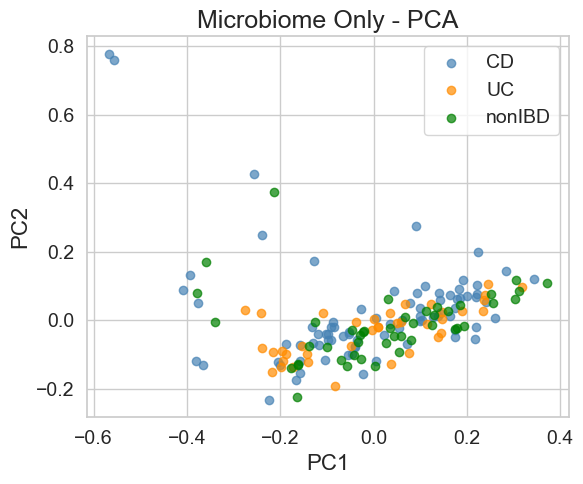

/Users/hector/mambaforge/envs/microbiologia_predictiva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


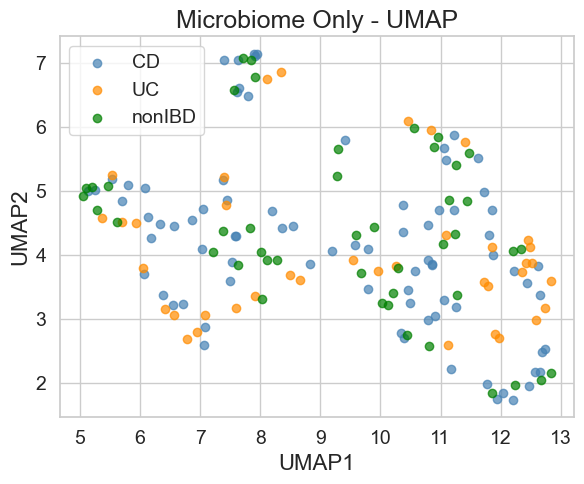

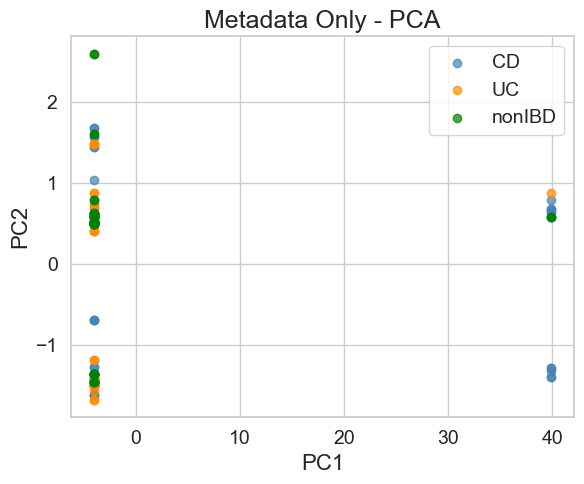

/Users/hector/mambaforge/envs/microbiologia_predictiva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


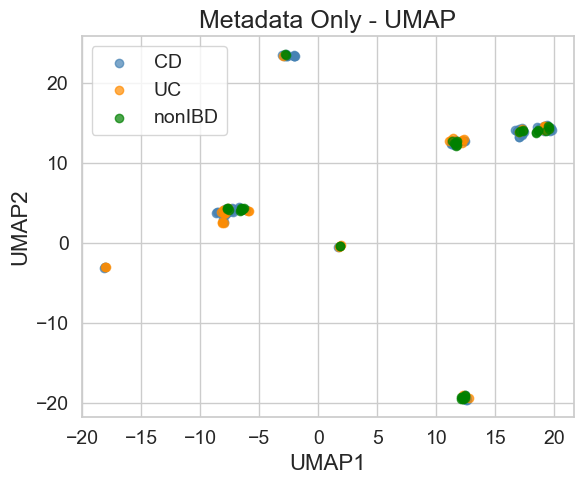

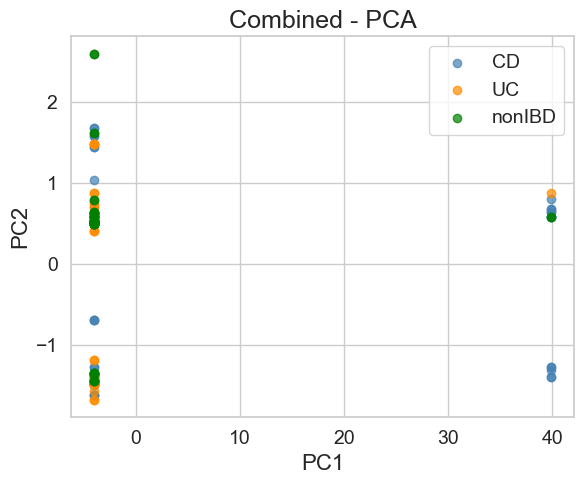

/Users/hector/mambaforge/envs/microbiologia_predictiva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


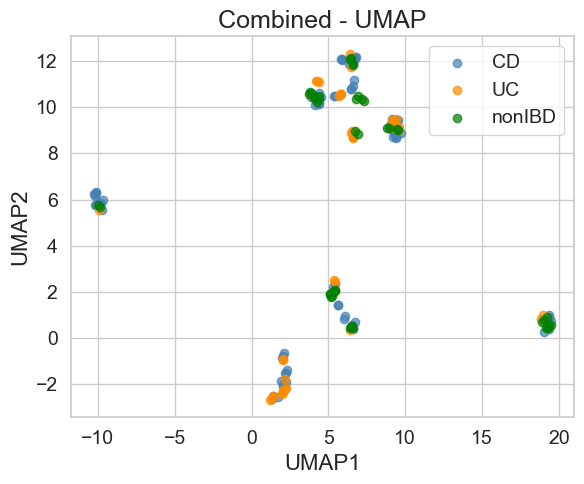

In [117]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Encode labels once
# -----------------------
y_codes = y.cat.codes
label_names = y.cat.categories.tolist()

colors = ["steelblue", "darkorange", "green"]

# -----------------------
# Plot function
# -----------------------
def plot_embeddings(X, y_codes, label_names, title_prefix):
    
    # ===== PCA =====
    pca = PCA(n_components=2, random_state=42)
    coords_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(6,5))
    
    for i, label in enumerate(np.unique(y_codes)):
        idx = y_codes == label
        plt.scatter(coords_pca[idx,0], coords_pca[idx,1],
                    label=label_names[label],
                    alpha=0.7,
                    color=colors[i])
    
    plt.title(f"{title_prefix} - PCA", fontsize=18)
    plt.xlabel("PC1", fontsize=16)
    plt.ylabel("PC2", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_PATH / f"{title_prefix}_PCA.png", dpi=300)
    plt.show()
    
    # ===== UMAP =====
    reducer = umap.UMAP(random_state=42)
    coords_umap = reducer.fit_transform(X)
    
    plt.figure(figsize=(6,5))
    
    for i, label in enumerate(np.unique(y_codes)):
        idx = y_codes == label
        plt.scatter(coords_umap[idx,0], coords_umap[idx,1],
                    label=label_names[label],
                    alpha=0.7,
                    color=colors[i])
    
    plt.title(f"{title_prefix} - UMAP", fontsize=18)
    plt.xlabel("UMAP1", fontsize=16)
    plt.ylabel("UMAP2", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_PATH / f"{title_prefix}_UMAP.png", dpi=300)
    plt.show()

# -----------------------
# RUN FOR ALL DATASETS
# -----------------------
plot_embeddings(X_micro, y_codes, label_names, "Microbiome Only")
plot_embeddings(X_meta, y_codes, label_names, "Metadata Only")
plot_embeddings(X_combined, y_codes, label_names, "Combined")

# ROC Curves

In [144]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_auc(X, y, title):
    
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Encode labels to integers
    y_codes = y.cat.codes
    n_classes = len(y.cat.categories)
    
    # Binarize labels (for ROC)
    y_bin = label_binarize(y_codes, classes=np.arange(n_classes))
    
    # Cross-validated predicted probabilities
    y_proba = cross_val_predict(
        model, X, y_codes,
        cv=cv,
        method="predict_proba"
    )
    
    # Compute ROC curves
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    
    print(f"\n=== {title} ROC-AUC ===")
    for i, class_name in enumerate(y.cat.categories):
        print(f"{class_name}: AUC = {roc_auc[i]:.3f}")
    print(f"Macro-average AUC: {macro_auc:.3f}")
    
    # Plot
    plt.figure(figsize=(6,5))
    
    colors = ["steelblue", "darkorange", "green"]
    
    for i, class_name in enumerate(y.cat.categories):
        plt.plot(
            fpr[i], tpr[i],
            color=colors[i],
            lw=2,
            label=f"{class_name} (AUC = {roc_auc[i]:.2f})"
        )
    
    plt.plot(all_fpr, mean_tpr,
             color="black",
             linestyle="--",
             label=f"Macro avg (AUC = {macro_auc:.2f})")
    
    plt.plot([0,1], [0,1], "k--", alpha=0.5)
    
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(f"{title}", fontsize=18)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_PATH / f"{title}_ROC_AUC.png", dpi=300)
    plt.show()


=== Microbiome Only ROC-AUC ===
CD: AUC = 0.826
UC: AUC = 0.840
nonIBD: AUC = 0.795
Macro-average AUC: 0.822


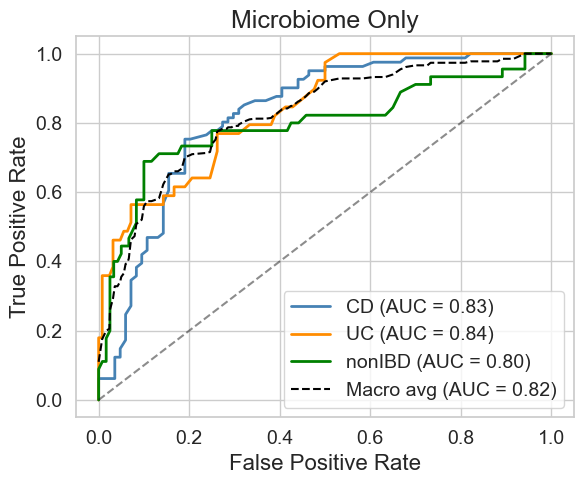


=== Metadata Only ROC-AUC ===
CD: AUC = 0.702
UC: AUC = 0.877
nonIBD: AUC = 0.872
Macro-average AUC: 0.819


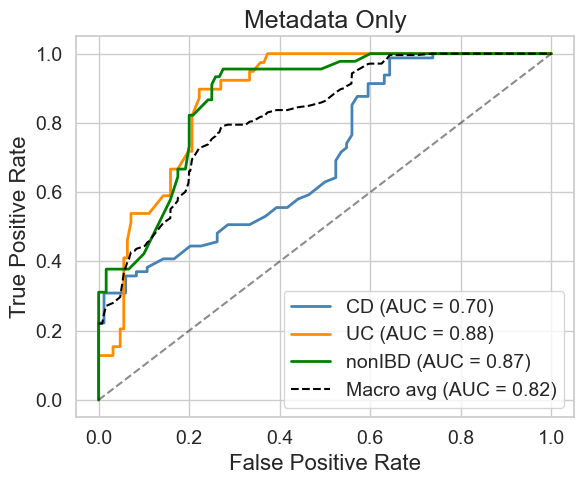


=== Combined Model ROC-AUC ===
CD: AUC = 0.836
UC: AUC = 0.817
nonIBD: AUC = 0.784
Macro-average AUC: 0.814


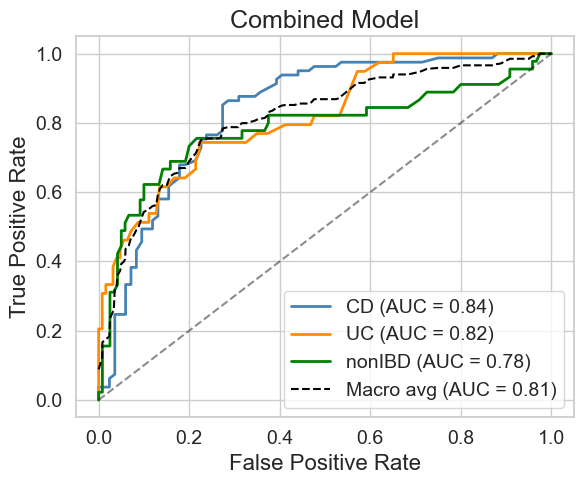

In [127]:
plot_roc_auc(X_micro, y, "Microbiome Only")
plot_roc_auc(X_meta, y, "Metadata Only")
plot_roc_auc(X_combined, y, "Combined Model")

# Feature importance

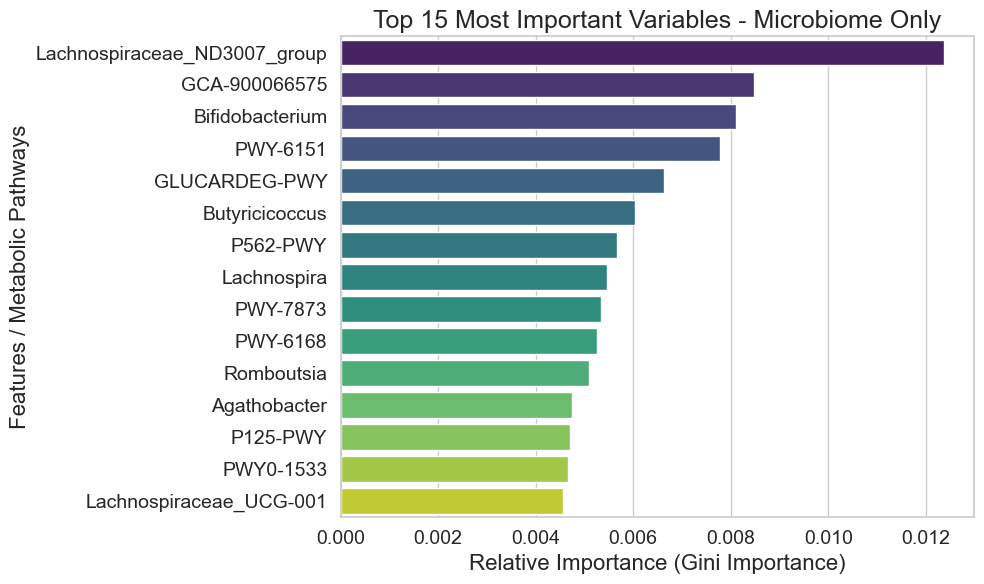

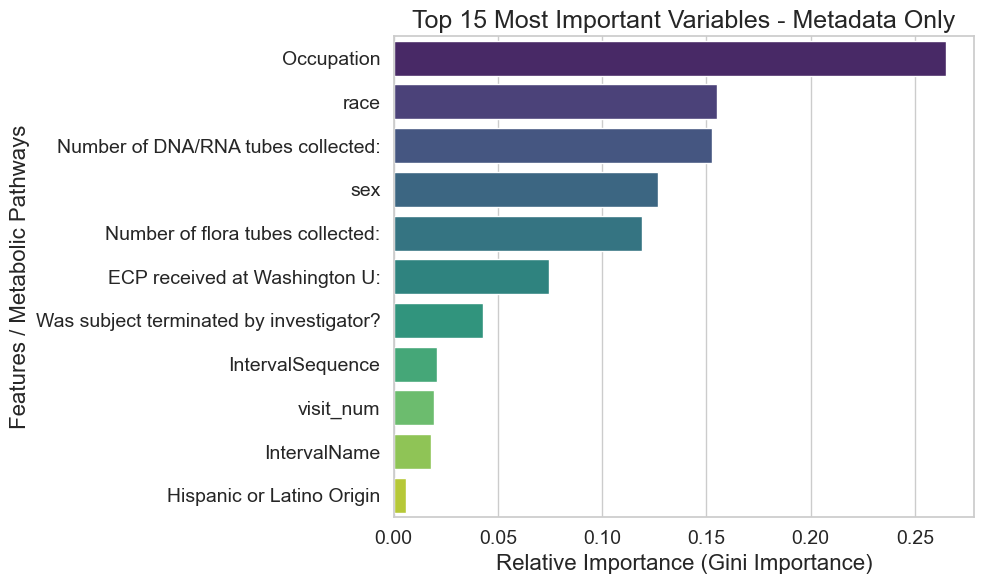

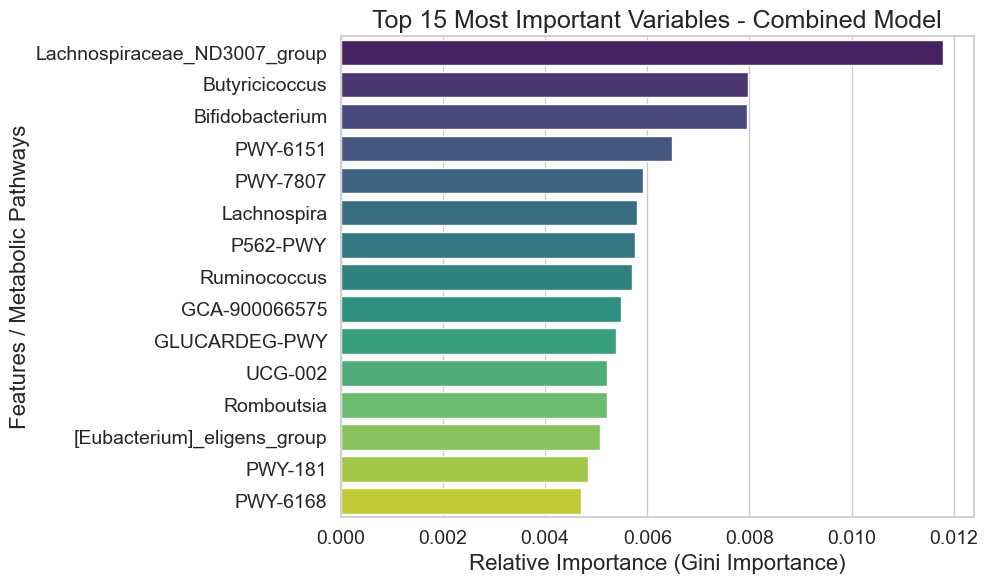

In [ ]:
def plot_feature_importance(X, y, title, top_n=15):
    # 1. Train the model
    # We use 300 estimators for stable importance scores
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    # 2. Extract feature importance
    # This uses Mean Decrease in Impurity (Gini Importance)
    importances = model.feature_importances_
    feature_names = X.columns
    
    # 3. Create a DataFrame for streamlined plotting with Seaborn
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).head(top_n)
    
    # 4. Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    
    # Enhanced formatting for presentation readability
    plt.title(f"Top {top_n} Most Important Variables - {title}", fontsize=18)
    plt.xlabel("Relative Importance (Gini Importance)", fontsize=16) 
    plt.ylabel("Features / Metabolic Pathways", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    
    # Save the figure with a clear, descriptive filename
    # Ensure FIG_PATH is predefined in your environment
    file_name = f"Feature_Importance_{title.replace(' ', '_')}.png"
    plt.savefig(FIG_PATH / file_name, dpi=300)
    plt.show()

# -----------------------
# EXECUTION FOR THE 3 MODELS
# -----------------------
plot_feature_importance(X_micro, y, "Microbiome Only")
plot_feature_importance(X_meta, y, "Metadata Only")
plot_feature_importance(X_combined, y, "Combined Model")

# SHAP plots

Generando Beeswarm para: CD...


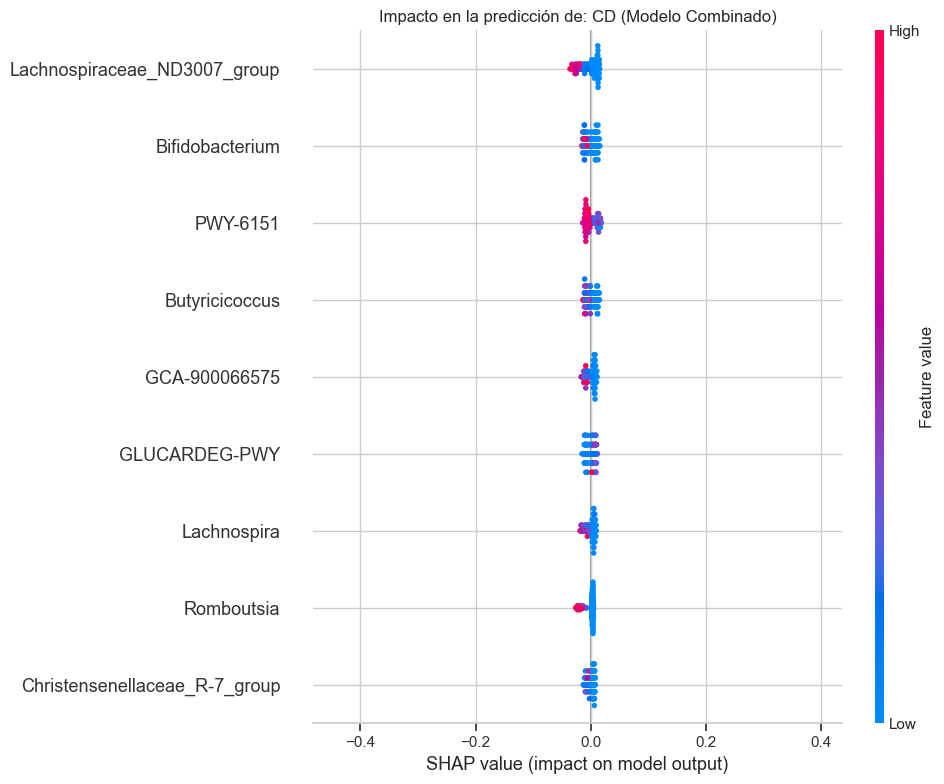

Generando Beeswarm para: UC...


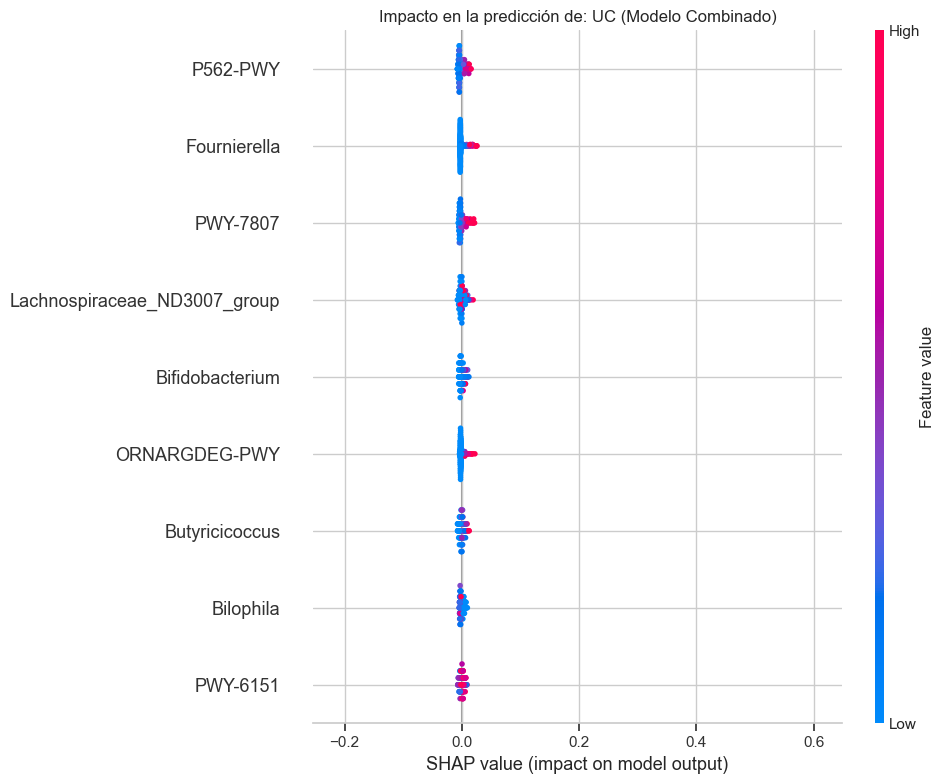

Generando Beeswarm para: nonIBD...


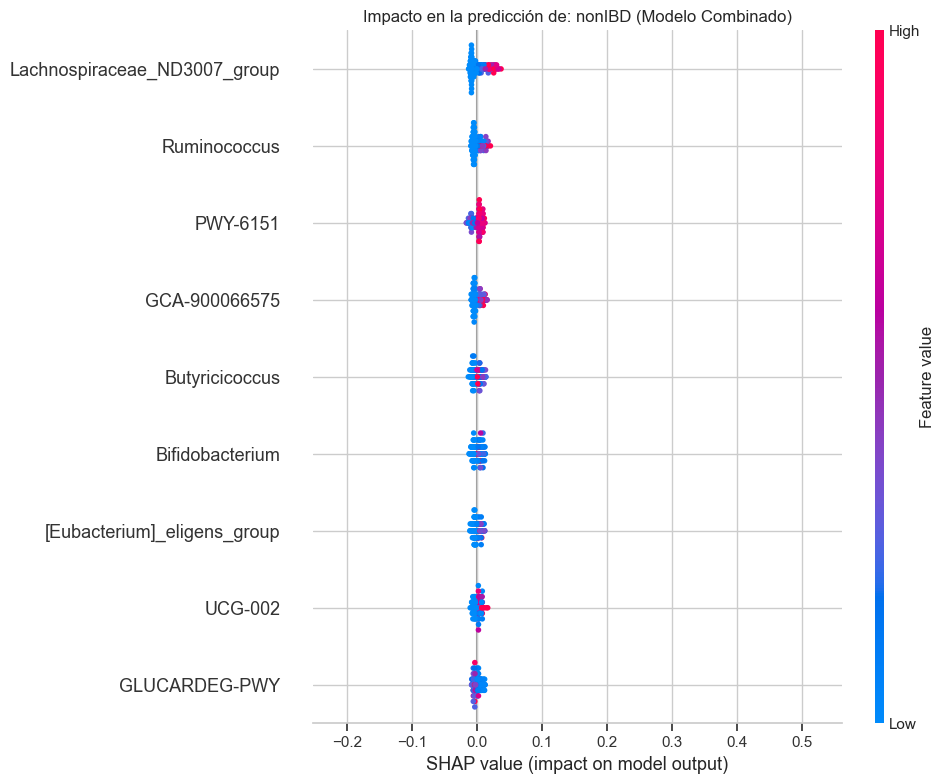

In [138]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def generate_shap_beeswarm(X, y, title):
    # 1. Entrenar el modelo
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    # 2. Crear el Explainer
    explainer = shap.TreeExplainer(model)
    
    # 3. Calcular los shap_values
    # check_additivity=False es vital para evitar errores de RF
    # approximate=True puede acelerarlo si tarda mucho
    shap_results = explainer(X, check_additivity=False)
    
    class_names = y.cat.categories.tolist()
    
    # 4. Iterar sobre cada clase para crear su propio Beeswarm
    for i, class_label in enumerate(class_names):
        print(f"Generando Beeswarm para: {class_label}...")
        plt.figure(figsize=(10, 8))
        
        # EL TRUCO: Creamos un objeto Explanation "falso" para la clase 'i'
        # Esto es necesario porque beeswarm() no maneja bien los outputs 3D de RF multiclase
        # shap_results[:, :, i] extrae la matriz de valores SHAP para la clase 'i'
        exp_class = shap.Explanation(
            shap_results[:, :, i].values,  # Los valores SHAP
            shap_results.base_values[:, i], # El valor base
            data=X,                        # Los datos originales
            feature_names=X.columns.tolist() # Nombres de las columnas
        )
        
        # 5. Graficar con beeswarm moderno
        # max_display=15 muestra las top 15 para que sea legible
        shap.plots.beeswarm(exp_class, max_display=10, show=False, plot_size=None)
        ax = plt.gca()
        yticks = ax.get_yticklabels()
        if "features" in yticks[0].get_text(): # SHAP suele ponerla al inicio de la lista de ticks
            ax.set_ylim(0.5, len(yticks) - 0.5)
            
        # Ajustes de Matplotlib
        plt.title(f"Impacto en la predicción de: {class_label} (Modelo Combinado)")
        plt.tight_layout()
        
        # Opcional: Guardar la imagen para la presentación
        # plt.savefig(f"SHAP_Beeswarm_{class_label}.png", dpi=300)
        
        plt.show()

# -----------------------
# EJECUCIÓN
# -----------------------
generate_shap_beeswarm(X_combined, y, "Combined Model")

## Analysis of clinical features related with disease

In [ ]:
diagnosis = df_biology['diagnosis'].unique().tolist()
print("Unique diagnosis categories:", diagnosis)

Unique diagnosis categories: ['CD', 'UC', 'nonIBD']


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Define exactly what you want to exlcude
to_exclude = ['diagnosis', 'External ID', 'sample-id', 'Project', 'stool_id', 'ProjectSpecificID', 'site_sub_coll']

# Get all available columns that are NOT in the exclusion list
available_features = [col for col in df_biology.columns if col not in to_exclude]

# Separate them into numeric and categorical based ONLY on available_features
X_subset = df_biology[available_features]

numeric_features = X_subset.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_subset.select_dtypes(include=['object', 'category']).columns.tolist()

y = df_biology['diagnosis']

# Prepare X and Encode Categories
X_final = X_subset.copy()
for col in categorical_features:
    X_final[col] = X_final[col].astype('category').cat.codes

# Fit the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_final, y)

# Rank them
importances = pd.Series(model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
print(importances.head(15))

Have samples been sent for histopathology?    0.011513
Lachnospira                                   0.010103
PWY-6565                                      0.009661
Bifidobacterium                               0.008841
Lachnospiraceae_ND3007_group                  0.008264
GLUCARDEG-PWY                                 0.007809
PWY0-41                                       0.007038
PWY-6151                                      0.006951
PWY-7874                                      0.006819
NONOXIPENT-PWY                                0.006597
DHGLUCONATE-PYR-CAT-PWY                       0.006149
Erysipelatoclostridium                        0.006144
Fournierella                                  0.005881
[Eubacterium]_eligens_group                   0.005805
PWY-6608                                      0.005286
dtype: float64


# Focus on Top features

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report


# Select top features

top_features = importances.sort_values(ascending=False).head(50).index
X_reduced = X_final[top_features]


# Define target
y = df_biology['diagnosis'].astype('category').cat.codes

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

model.fit(X_train, y_train)

# -----------------------
# 5. Evaluate on test set
# -----------------------
y_pred = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9090909090909091

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       1.00      0.75      0.86         8
           2       0.90      1.00      0.95         9

    accuracy                           0.91        33
   macro avg       0.93      0.90      0.90        33
weighted avg       0.92      0.91      0.91        33



# Cross validation

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_reduced, y, cv=cv, scoring='accuracy')

print("CV Accuracy:", scores.mean(), "+/-", scores.std())

CV Accuracy: 0.7454545454545454 +/- 0.04110503020075921


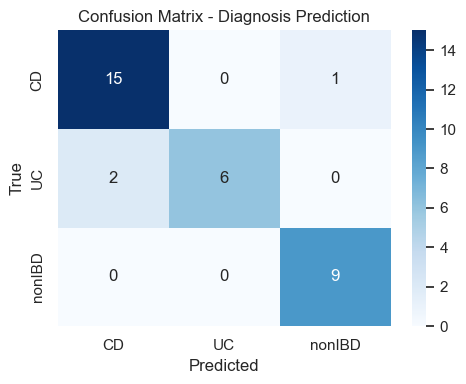

In [ ]:
from sklearn.metrics import confusion_matrix


# correct predictions (IMPORTANT)
y_pred = model.predict(X_test)

# correct class order
classes = df_biology['diagnosis'].astype('category').cat.categories

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Diagnosis Prediction")
plt.tight_layout()
plt.show()

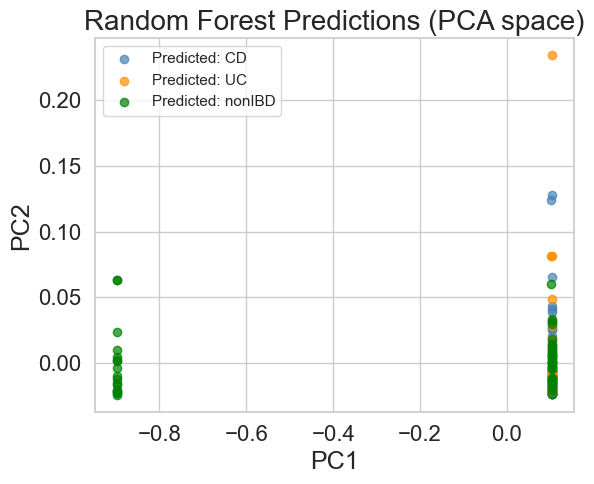

In [33]:
# Plot classification in PCA space

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

y_true = df_merged.loc[X_reduced.index, 'diagnosis'].astype('category')
classes = y_true.cat.categories

coords = PCA(n_components=2).fit_transform(X_reduced)

y_pred = model.predict(X_reduced)

color_map = {
    0: "steelblue",
    1: "darkorange",
    2: "green"
}

plt.figure(figsize=(6,5))

for cls in np.unique(y_pred):
    idx = y_pred == cls
    plt.scatter(
        coords[idx, 0],
        coords[idx, 1],
        label=f"Predicted: {classes[cls]}",
        alpha=0.7,
        color=color_map.get(cls, "gray")
    )

plt.legend()
plt.title("Random Forest Predictions (PCA space)", fontsize=20)
plt.xlabel("PC1", fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel("PC2", fontsize=18)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

/Users/hector/mambaforge/envs/microbiologia_predictiva/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


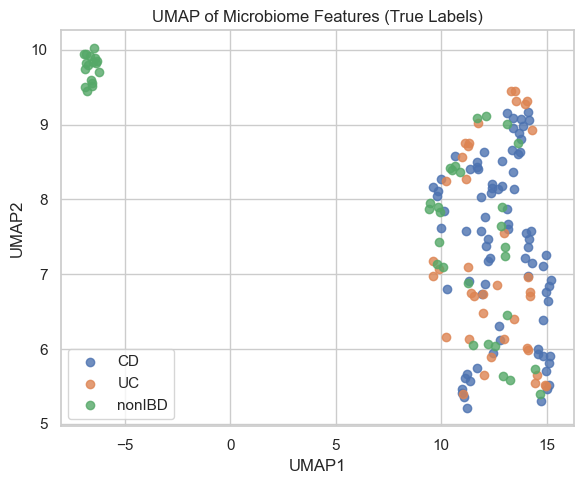

In [ ]:
import umap
import matplotlib.pyplot as plt

embedding = umap.UMAP(random_state=42).fit_transform(X_reduced)

y_true = df_biology.loc[X_reduced.index, 'diagnosis'].astype('category')
classes = y_true.cat.categories

plt.figure(figsize=(6,5))

for i, cls in enumerate(classes):
    idx = y_true.cat.codes == i
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=cls,
        alpha=0.8
    )

plt.title("UMAP of Microbiome Features (True Labels)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.tight_layout()
plt.show()

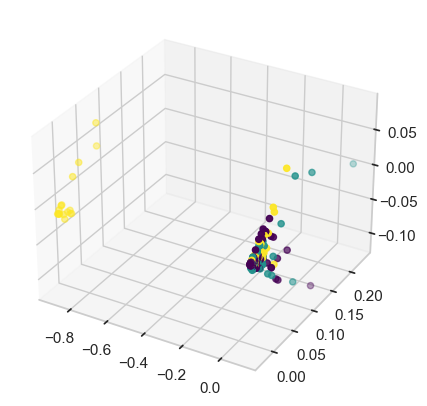

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=3).fit_transform(X_reduced)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(coords[:,0], coords[:,1], coords[:,2],
           c=y.astype('category').cat.codes,
           cmap='viridis')

plt.show()

# Logistic Regressions

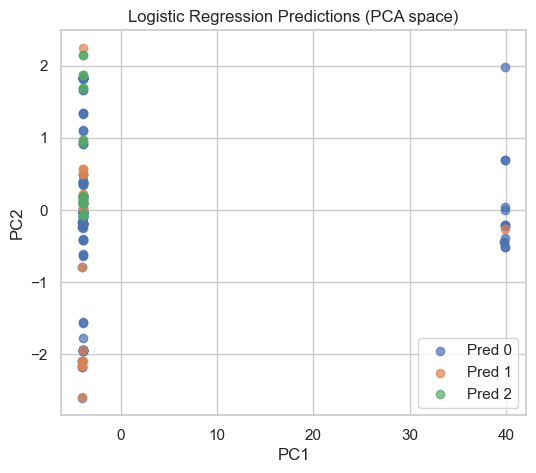

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_final, y)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=2).fit_transform(X_final)

y_pred = lr.predict(X_final)

plt.figure(figsize=(6,5))

for cls in np.unique(y_pred):
    idx = y_pred == cls
    plt.scatter(coords[idx,0], coords[idx,1],
                label=f"Pred {cls}",
                alpha=0.7)

plt.legend()
plt.title("Logistic Regression Predictions (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
plt.figure(figsize=(6,5))

for cls in np.unique(y):
    idx = y == cls
    plt.scatter(coords[idx,0], coords[idx,1],
                label=f"True {cls}",
                alpha=0.7)

plt.legend()
plt.title("True Diagnosis (PCA space)")
plt.show()

In [ ]:
import pandas as pd

coef = pd.Series(lr.coef_[0], index=X_final.columns)
coef.sort_values().head(15).plot(kind="barh")
plt.title("Most Negative Features (protective)")
plt.show()

coef.sort_values(ascending=False).head(15).plot(kind="barh")
plt.title("Most Positive Features (risk)")
plt.show()

# ROC curve

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

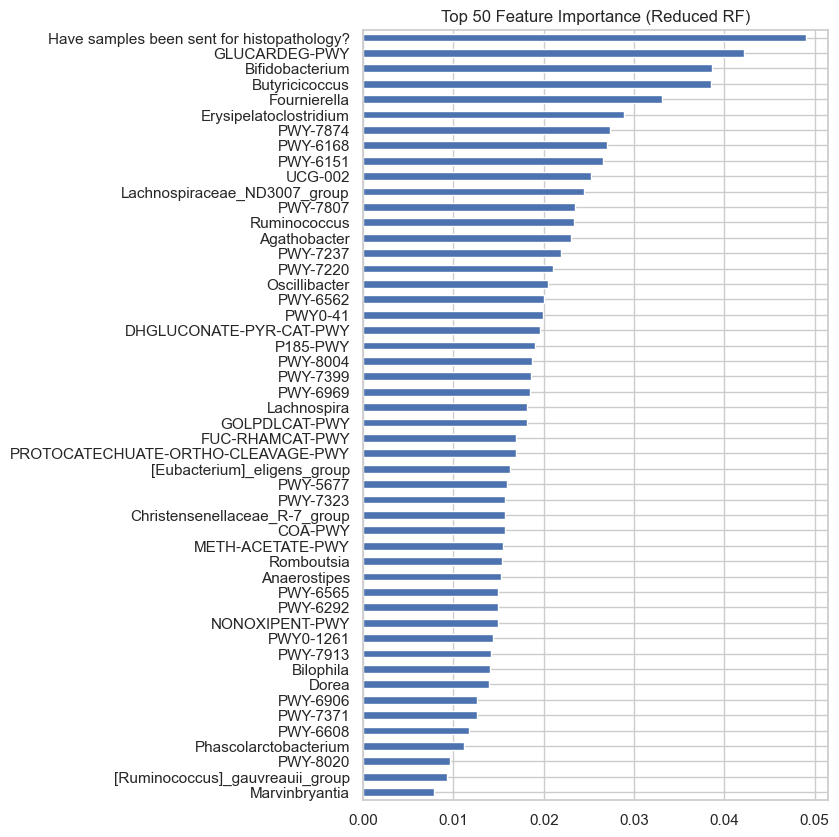

In [ ]:
importances = pd.Series(model.feature_importances_, index=top_features)
importances.sort_values().plot(kind="barh", figsize=(6,10))
plt.title("Top 50 Feature Importance (Reduced RF)")
plt.show()

# Importance

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# We use the Gini importance 
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Top 15 Predictores (Gini Importance)")
plt.xlabel("Importancia (Suma = 1)")
plt.show()

# shap plots

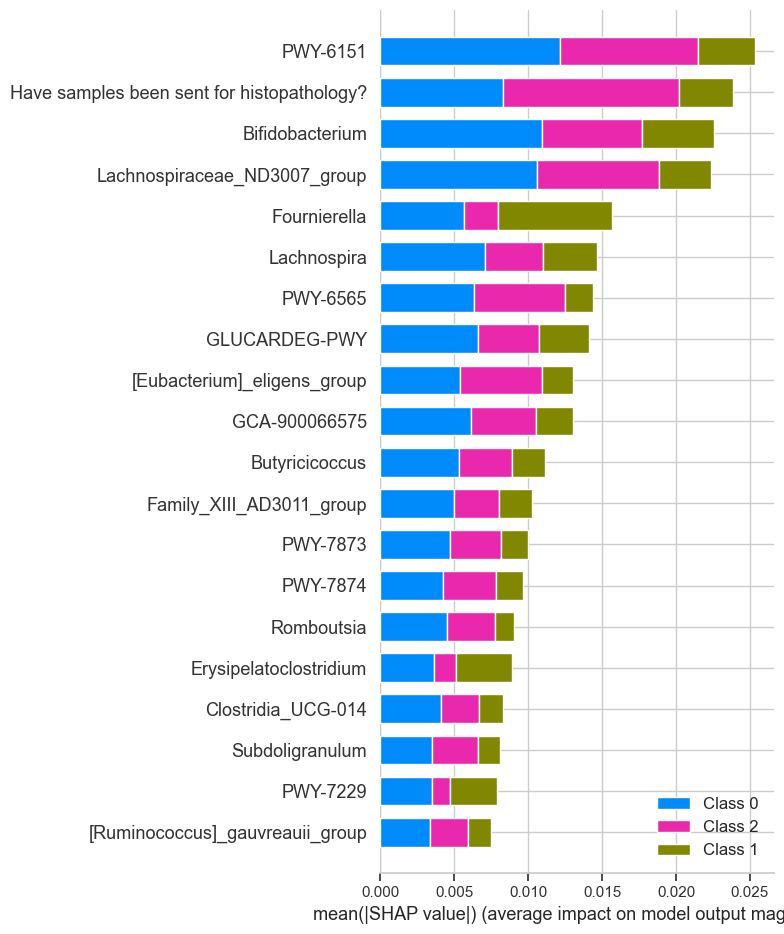

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 3 and the array at index 1 has size 16

In [38]:
import shap

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_final, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_final)
shap.summary_plot(shap_values, X_final, plot_type="bar")
feat = importances.index[0]

shap.dependence_plot(feat, shap_values, X_final)

# AA

/Users/hector/mambaforge/envs/microbiologia_predictiva/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


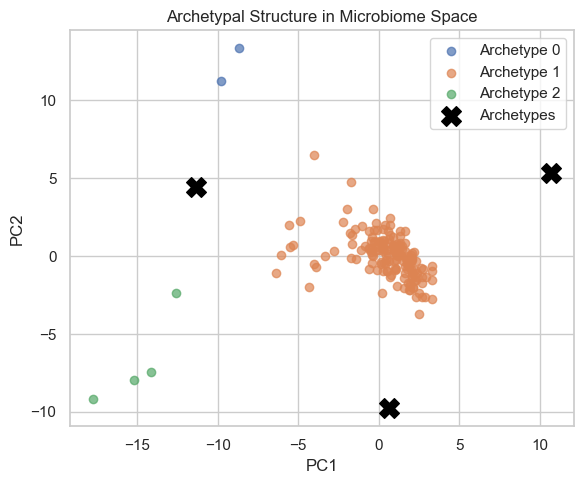

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from archetypes import AA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_reduced.copy()

# better: consider CLR or log instead of StandardScaler
X_scaled = StandardScaler().fit_transform(X)

aa = AA(n_archetypes=3, max_iter=200, random_state=42)
aa.fit(X_scaled)

Z = aa.archetypes_
W = aa.alphas_

labels = np.argmax(W, axis=1)

coords = PCA(n_components=2).fit_transform(X_scaled)
coords_Z = PCA(n_components=2).fit_transform(Z)

plt.figure(figsize=(6,5))

for i in range(3):
    idx = labels == i
    plt.scatter(coords[idx,0], coords[idx,1],
                label=f"Archetype {i}",
                alpha=0.7)

plt.scatter(coords_Z[:,0], coords_Z[:,1],
            c="black", marker="X", s=200, label="Archetypes")

plt.title("Archetypal Structure in Microbiome Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

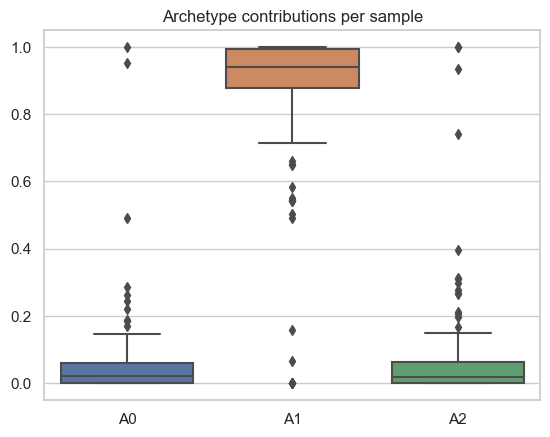

In [49]:
import seaborn as sns

W_df = pd.DataFrame(W, columns=[f"A{i}" for i in range(3)])

sns.boxplot(data=W_df)
plt.title("Archetype contributions per sample")
plt.show()

In [50]:
W = aa.alphas_
Z = aa.archetypes_

In [51]:
archetypes_df = pd.DataFrame(
    Z,
    columns=X_reduced.columns
)

In [54]:
W_df = pd.DataFrame(W, columns=[f"A{i}" for i in range(W.shape[1])])
W_df

,A0,A1,A2
0,0.077650,0.862291,0.060058
1,0.075768,0.877611,0.046621
2,0.095262,0.835309,0.069430
3,0.187308,0.549268,0.263424
4,0.183365,0.502660,0.313975
...,...,...,...
160,0.068039,0.922615,0.009346
161,0.054290,0.933163,0.012547
162,0.002305,0.997695,0.000000
163,0.010297,0.960942,0.028762


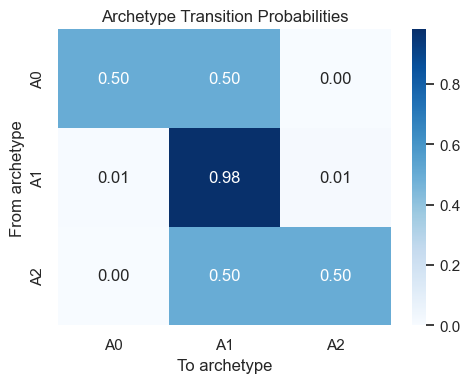

In [57]:
import numpy as np
import pandas as pd

# W = archetype weights from AA
states = np.argmax(W, axis=1)
from collections import Counter

transitions = Counter()

for i in range(len(states) - 1):
    transitions[(states[i], states[i+1])] += 1

n_states = len(np.unique(states))

T = pd.DataFrame(
    0.0,
    index=[f"A{i}" for i in range(n_states)],
    columns=[f"A{i}" for i in range(n_states)]
)

for (i, j), v in transitions.items():
    T.iloc[i, j] = v

T = T.div(T.sum(axis=1).replace(0, np.nan), axis=0)
T = T.fillna(0)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    T,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Archetype Transition Probabilities")
plt.xlabel("To archetype")
plt.ylabel("From archetype")
plt.tight_layout()
plt.show()

In [58]:
W_df = pd.DataFrame(W, columns=[f"A{i}" for i in range(W.shape[1])])

# compute transition of dominant archetype over sliding window
window = 5
soft_transitions = Counter()

for i in range(len(W_df) - window):
    from_state = np.argmax(W_df.iloc[i].values)
    to_state = np.argmax(W_df.iloc[i + window].values)
    soft_transitions[(from_state, to_state)] += 1

# Transitions network

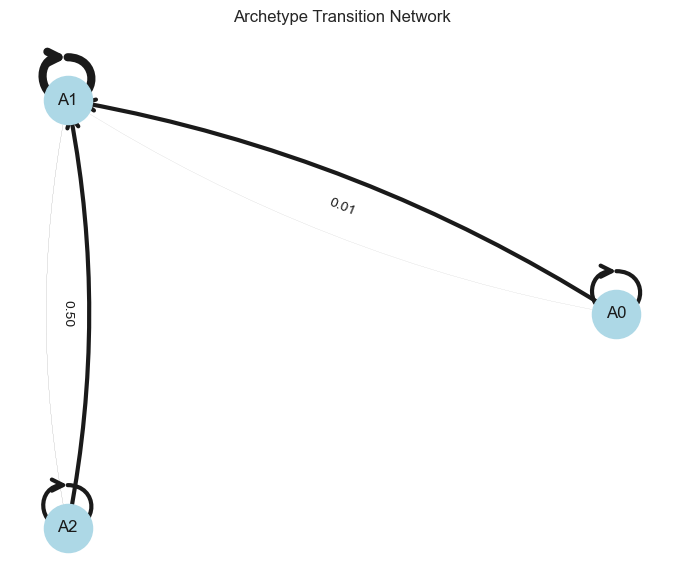

In [69]:
import numpy as np
import pandas as pd
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------
# 1. Archetype states
# -----------------------
states = np.argmax(W, axis=1)

# -----------------------
# 2. Transition counts (INCLUDING self transitions correctly)
# -----------------------
transitions = Counter()

for i in range(len(states) - 1):
    transitions[(states[i], states[i+1])] += 1

# -----------------------
# 3. Build probability matrix
# -----------------------
n_states = len(np.unique(states))

T = pd.DataFrame(
    0.0,
    index=[f"A{i}" for i in range(n_states)],
    columns=[f"A{i}" for i in range(n_states)]
)

for (i, j), v in transitions.items():
    T.iloc[i, j] = v

# row-normalize → P(j | i)
T = T.div(T.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# -----------------------
# 4. Build graph
# -----------------------
G = nx.DiGraph()

for i in range(n_states):
    for j in range(n_states):
        p = T.iloc[i, j]
        if p > 0:
            G.add_edge(f"A{i}", f"A{j}", weight=p)

# -----------------------
# 5. Plot
# -----------------------
plt.figure(figsize=(7,6))
pos = nx.circular_layout(G)

edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="lightblue")
nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=20,
    width=[w * 6 for w in weights],
    connectionstyle="arc3,rad=0.1"
)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Archetype Transition Network")
plt.axis("off")
plt.tight_layout()
plt.show()

# Transitions based on distance

In [75]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# reduce dimensionality
X_pca = PCA(n_components=10).fit_transform(X_final)

# cluster phenotypes
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

In [77]:
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

# Bray-Curtis-like distance (for relative abundances)
D = pairwise_distances(X_final, metric="braycurtis")

clusters = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="average"
).fit_predict(D)

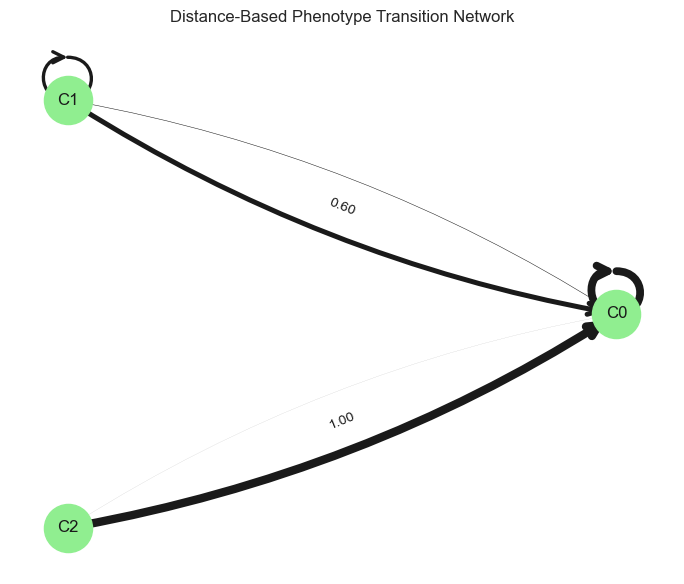

In [78]:
from collections import Counter
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# use clusters instead of archetypes
states_cluster = clusters

transitions = Counter()

for i in range(len(states_cluster) - 1):
    transitions[(states_cluster[i], states_cluster[i+1])] += 1

# matrix
n_states = len(np.unique(states_cluster))

T = pd.DataFrame(
    0.0,
    index=[f"C{i}" for i in range(n_states)],
    columns=[f"C{i}" for i in range(n_states)]
)

for (i, j), v in transitions.items():
    T.iloc[i, j] = v

T = T.div(T.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# graph
G = nx.DiGraph()

for i in range(n_states):
    for j in range(n_states):
        p = T.iloc[i, j]
        if p > 0:
            G.add_edge(f"C{i}", f"C{j}", weight=p)

# plot
plt.figure(figsize=(7,6))
pos = nx.circular_layout(G)

edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="lightgreen")
nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=20,
    width=[w * 6 for w in weights],
    connectionstyle="arc3,rad=0.1"
)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Distance-Based Phenotype Transition Network")
plt.axis("off")
plt.tight_layout()
plt.show()